## <font size=5><strong>Heart Disease Prediction — Corrected & Reproducible Pipeline</strong></font>

## I. Importing Essential Libraries

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility seed ──────────────────────────────────────────
RANDOM_STATE = 42

# ── Library versions (reproducibility) ───────────────────────────
import sklearn, scipy
print(f"Python      : 3.x  (use 3.9+)")
print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"scipy       : {scipy.__version__}")


Python      : 3.x  (use 3.9+)
numpy       : 2.3.1
pandas      : 2.3.1
scikit-learn: 1.7.1
scipy       : 1.16.1


## II. Importing and Understanding the Dataset

In [44]:
dataset = pd.read_csv("heart.csv")

#### Verify it is a DataFrame

In [45]:
type(dataset)

pandas.core.frame.DataFrame

#### Shape of dataset

In [46]:
dataset.shape

(1025, 14)

#### First few rows

In [47]:
dataset.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [48]:
dataset.sample(5, random_state=RANDOM_STATE)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
527,62,0,0,124,209,0,1,163,0,0.0,2,0,2,1
359,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
447,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
621,48,1,0,130,256,1,0,150,1,0.0,2,2,3,0


#### Descriptive statistics

In [49]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [50]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [51]:
# Check for missing values
print("Missing values per column:")
print(dataset.isnull().sum())
print(f"\nTotal missing values: {dataset.isnull().sum().sum()}")


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


#### Column descriptions

In [52]:
info = [
    "age",
    "1: male, 0: female",
    "chest pain type: 0=typical angina, 1=atypical angina, 2=non-anginal pain, 3=asymptomatic",
    "resting blood pressure (mm Hg)",
    "serum cholesterol in mg/dl",
    "fasting blood sugar > 120 mg/dl (1=true, 0=false)",
    "resting ECG results (0=normal, 1=ST-T abnormality, 2=LV hypertrophy)",
    "maximum heart rate achieved",
    "exercise-induced angina (1=yes, 0=no)",
    "ST depression induced by exercise relative to rest",
    "slope of the peak exercise ST segment (0=upsloping, 1=flat, 2=downsloping)",
    "number of major vessels (0-3) coloured by fluoroscopy",
    "thalassemia (1=normal, 2=fixed defect, 3=reversible defect)"
]
for i in range(len(info)):
    print(f"{dataset.columns[i]:<12}:\t{info[i]}")


age         :	age
sex         :	1: male, 0: female
cp          :	chest pain type: 0=typical angina, 1=atypical angina, 2=non-anginal pain, 3=asymptomatic
trestbps    :	resting blood pressure (mm Hg)
chol        :	serum cholesterol in mg/dl
fbs         :	fasting blood sugar > 120 mg/dl (1=true, 0=false)
restecg     :	resting ECG results (0=normal, 1=ST-T abnormality, 2=LV hypertrophy)
thalach     :	maximum heart rate achieved
exang       :	exercise-induced angina (1=yes, 0=no)
oldpeak     :	ST depression induced by exercise relative to rest
slope       :	slope of the peak exercise ST segment (0=upsloping, 1=flat, 2=downsloping)
ca          :	number of major vessels (0-3) coloured by fluoroscopy
thal        :	thalassemia (1=normal, 2=fixed defect, 3=reversible defect)


## III. Exploratory Data Analysis (EDA)

### Target variable distribution

Total samples : 1025
No disease (0): 499  (48.68%)
Disease    (1): 526  (51.32%)


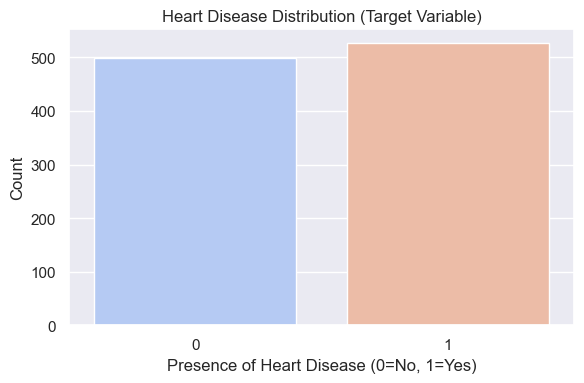

In [53]:
target_temp = dataset['target'].value_counts()
total = len(dataset)
print(f"Total samples : {total}")
print(f"No disease (0): {target_temp[0]}  ({round(target_temp[0]*100/total, 2)}%)")
print(f"Disease    (1): {target_temp[1]}  ({round(target_temp[1]*100/total, 2)}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x=dataset['target'], palette='coolwarm')
plt.title('Heart Disease Distribution (Target Variable)')
plt.xlabel('Presence of Heart Disease (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Sex vs. Target

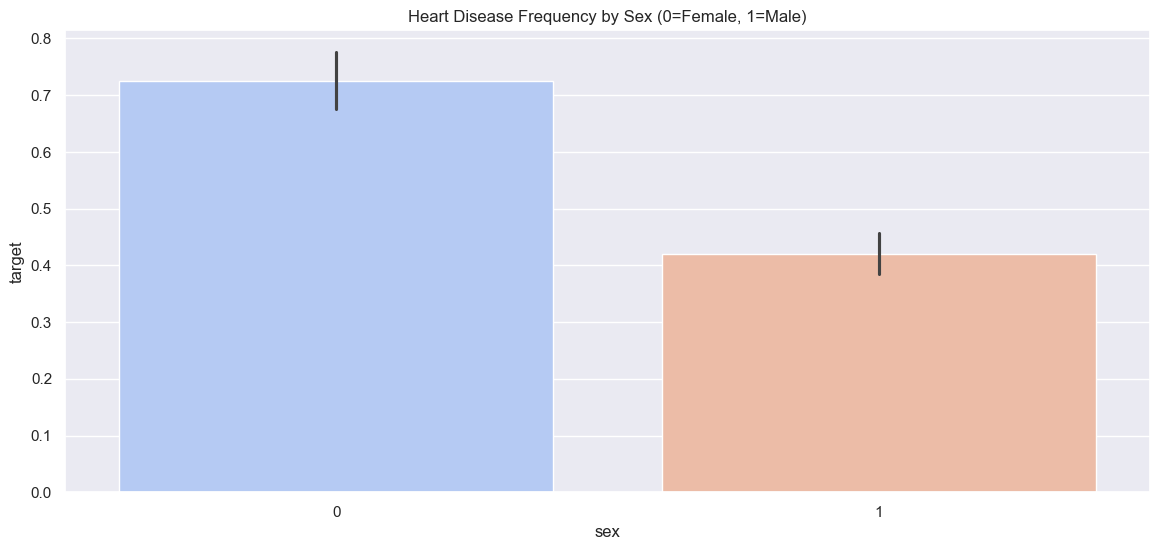

In [54]:
sns.barplot(x='sex', y='target', data=dataset, palette='coolwarm')
plt.title('Heart Disease Frequency by Sex (0=Female, 1=Male)')
plt.show()


##### Females are more likely to have heart problems than males in this dataset.

### Chest Pain Type vs. Target

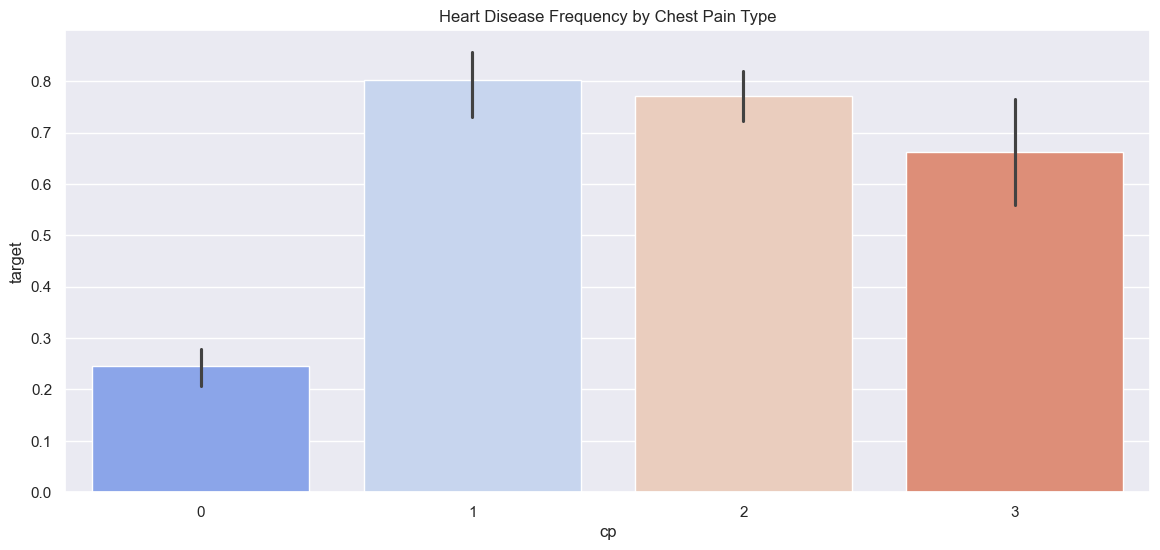

In [55]:
sns.barplot(x=dataset['cp'], y=dataset['target'], palette='coolwarm')
plt.title('Heart Disease Frequency by Chest Pain Type')
plt.show()


##### Chest pain type 0 (typical angina) is associated with fewer heart disease cases.

### FBS, RestECG, ExAng, Slope

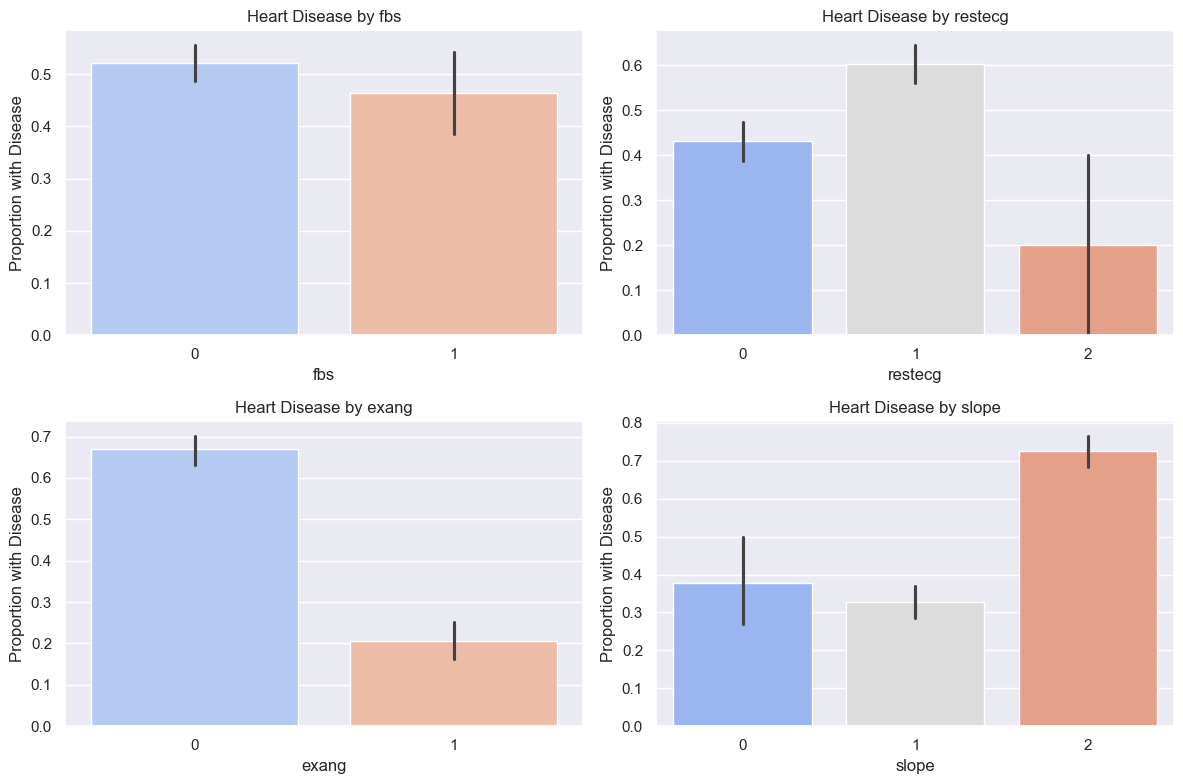

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ['fbs', 'restecg', 'exang', 'slope']):
    sns.barplot(x=dataset[col], y=dataset['target'], ax=ax, palette='coolwarm')
    ax.set_title(f'Heart Disease by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Proportion with Disease')
plt.tight_layout()
plt.show()


### CA and Thal features

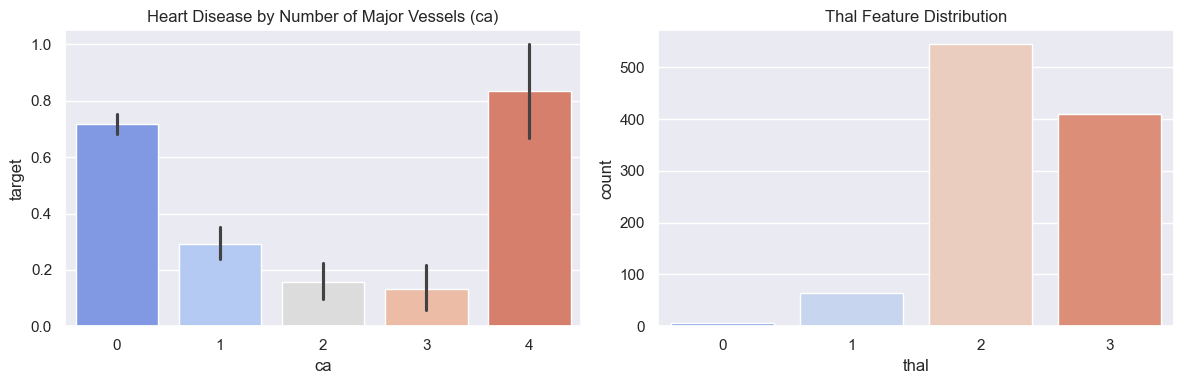

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=dataset['ca'], y=dataset['target'], ax=axes[0], palette='coolwarm')
axes[0].set_title('Heart Disease by Number of Major Vessels (ca)')
sns.countplot(x=dataset['thal'], ax=axes[1], palette='coolwarm')
axes[1].set_title('Thal Feature Distribution')
plt.tight_layout()
plt.show()


### Correlation Heatmap

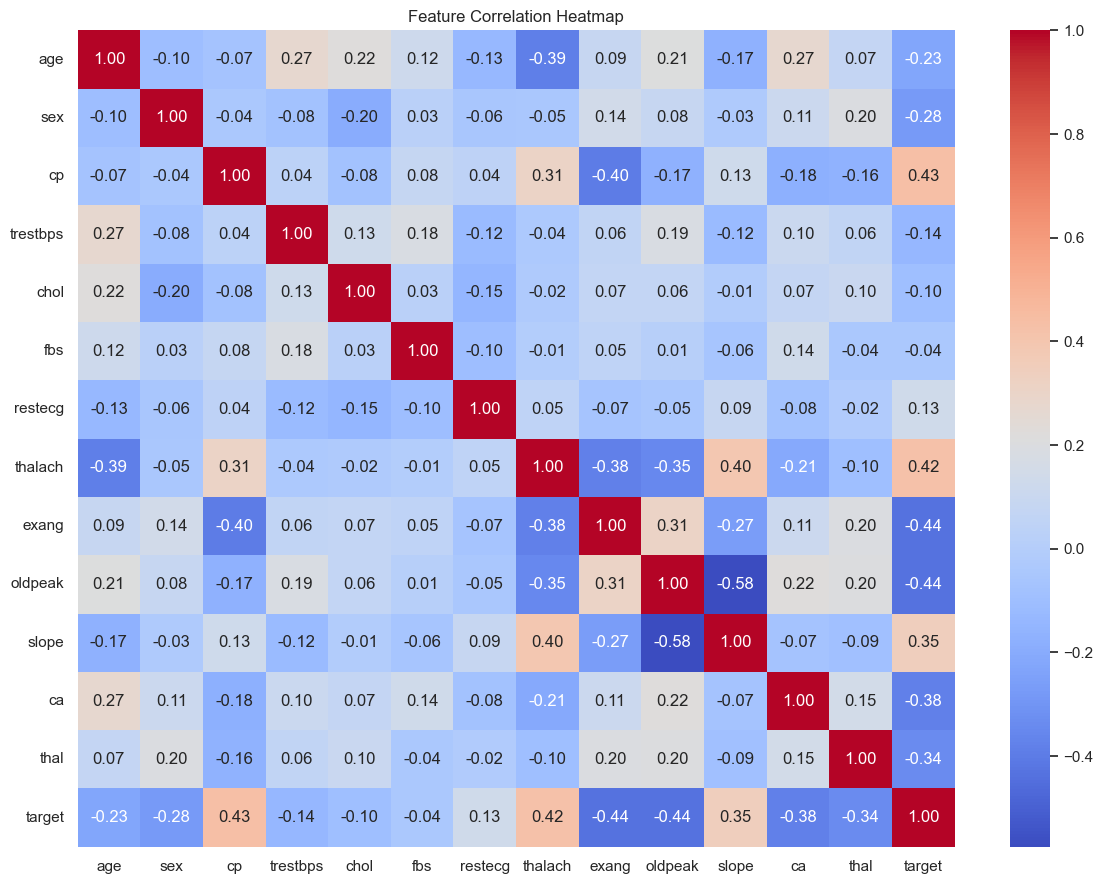


Correlation with target (absolute, sorted):
target      1.000000
oldpeak     0.438441
exang       0.438029
cp          0.434854
thalach     0.422895
ca          0.382085
slope       0.345512
thal        0.337838
sex         0.279501
age         0.229324
trestbps    0.138772
restecg     0.134468
chol        0.099966
fbs         0.041164
Name: target, dtype: float64


In [58]:
plt.figure(figsize=(12, 9))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()
print("\nCorrelation with target (absolute, sorted):")
print(dataset.corr()['target'].abs().sort_values(ascending=False))


### Age Distribution

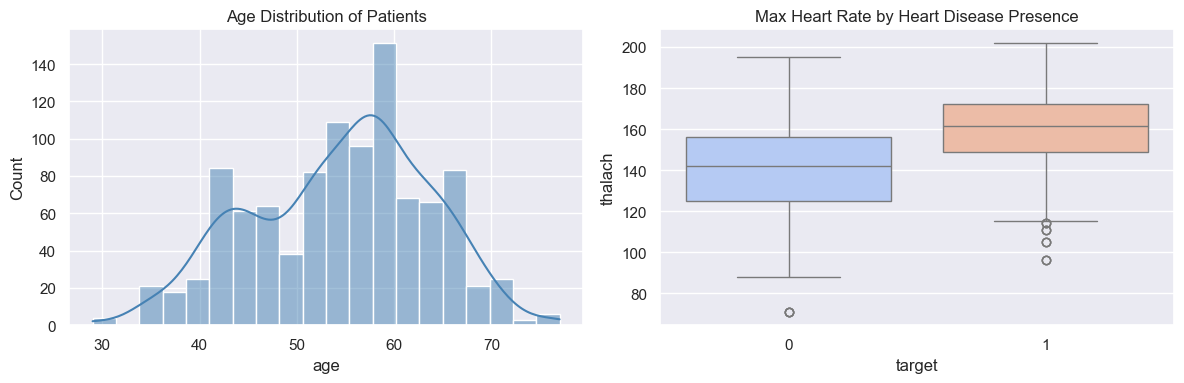

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(dataset['age'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution of Patients')
sns.boxplot(x=dataset['target'], y=dataset['thalach'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Max Heart Rate by Heart Disease Presence')
plt.tight_layout()
plt.show()


## IV. Data Preprocessing

The preprocessing pipeline:
1. IQR-based outlier removal on continuous features
2. One-hot encoding of categorical features (`drop_first=True`)
3. Feature / target split
4. StandardScaler applied **inside a Pipeline per fold** to prevent data leakage


### 4.1 IQR-Based Outlier Removal

In [60]:
# Outlier removal on continuous features using the 1.5×IQR rule
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print(f"Samples BEFORE outlier removal: {len(dataset)}")
print(f"Class distribution BEFORE: {dataset['target'].value_counts().to_dict()}\n")

mask = pd.Series([True] * len(dataset), index=dataset.index)
for col in continuous_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    col_mask = (dataset[col] >= lower) & (dataset[col] <= upper)
    removed = (~col_mask).sum()
    print(f"  {col:<12}: [{lower:.2f}, {upper:.2f}]  —  {removed} outlier(s) removed")
    mask &= col_mask

dataset_clean = dataset[mask].reset_index(drop=True)

print(f"\nSamples AFTER  outlier removal: {len(dataset_clean)}")
print(f"Samples removed               : {len(dataset) - len(dataset_clean)}")
print(f"Class distribution AFTER: {dataset_clean['target'].value_counts().to_dict()}")
ratio = dataset_clean['target'].value_counts(normalize=True) * 100
print(f"Class ratio AFTER — No Disease: {ratio[0]:.1f}%  |  Disease: {ratio[1]:.1f}%")


Samples BEFORE outlier removal: 1025
Class distribution BEFORE: {1: 526, 0: 499}

  age         : [28.50, 80.50]  —  0 outlier(s) removed
  trestbps    : [90.00, 170.00]  —  30 outlier(s) removed
  chol        : [115.00, 371.00]  —  16 outlier(s) removed
  thalach     : [81.00, 217.00]  —  4 outlier(s) removed
  oldpeak     : [-2.70, 4.50]  —  7 outlier(s) removed

Samples AFTER  outlier removal: 968
Samples removed               : 57
Class distribution AFTER: {1: 508, 0: 460}
Class ratio AFTER — No Disease: 47.5%  |  Disease: 52.5%


### 4.2 One-Hot Encoding of Categorical Features

The following features are categorical and are one-hot encoded with `drop_first=True`
to avoid the dummy-variable trap:

| Feature   | Values | Dummy columns created |
|-----------|--------|----------------------|
| cp        | 4      | cp_1, cp_2, cp_3 (3 dummies) |
| restecg   | 3      | restecg_1, restecg_2 (2 dummies) |
| slope     | 3      | slope_1, slope_2 (2 dummies) |
| thal      | 4      | thal_2, thal_3 (after drop_first) (2–3 dummies) |


In [61]:
cat_cols = ['cp', 'restecg', 'slope', 'thal']

dataset_enc = pd.get_dummies(dataset_clean, columns=cat_cols, drop_first=True)

dummy_cols = [c for c in dataset_enc.columns if any(c.startswith(p + '_') for p in cat_cols)]
print(f"Shape before encoding: {dataset_clean.shape}")
print(f"Shape after  encoding: {dataset_enc.shape}")
print(f"Dummy columns created ({len(dummy_cols)}): {dummy_cols}")


Shape before encoding: (968, 14)
Shape after  encoding: (968, 20)
Dummy columns created (10): ['cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']


### 4.3 Feature / Target Split

In [62]:
predictors = dataset_enc.drop('target', axis=1)
target_col = dataset_enc['target']

print(f"Features (X) shape : {predictors.shape}")
print(f"Target   (y) shape : {target_col.shape}")
print(f"Feature names      : {list(predictors.columns)}")


Features (X) shape : (968, 19)
Target   (y) shape : (968,)
Feature names      : ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']


## V. Model Fitting — 10-Fold Stratified Cross-Validation

**Evaluation strategy:** All models are evaluated using **10-fold stratified cross-validation only**
(no separate hold-out set). Metrics are reported as **mean ± standard deviation** across the 10 folds.

**Data leakage prevention:** `StandardScaler` is placed **inside a `Pipeline`** so that it is
fitted on the training folds only and applied to the test fold — never the other way around.

### Hyperparameter Summary

| Model | Key Hyperparameters |
|---|---|
| Logistic Regression | C=1.0, solver=lbfgs, max_iter=1000, random_state=42 |
| Naive Bayes | Default GaussianNB |
| SVM | kernel=RBF, C=1.0, gamma=scale, random_state=42 |
| K-Nearest Neighbors | n_neighbors=7 |
| Decision Tree | max_depth=5, random_state=42 |
| Random Forest | n_estimators=100, random_state=42 |
| XGBoost (GradientBoosting) | n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42 |
| Neural Network (MLP) | hidden_layer_sizes=(11,), activation=relu, max_iter=500, random_state=42 |


In [63]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ── 10-fold stratified CV ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# ── Scoring metrics ───────────────────────────────────────────────
scorers = {
    'accuracy' : make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall'   : make_scorer(recall_score,    average='macro', zero_division=0),
    'f1'       : make_scorer(f1_score,        average='macro', zero_division=0),
    'roc_auc'  : make_scorer(roc_auc_score),
}

# ── Model definitions — Scaler inside Pipeline (no leakage) ───────
models = {
    'Logistic Regression':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))]),

    'Naive Bayes':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', GaussianNB())]),

    'SVM (RBF, C=1.0)':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', SVC(kernel='rbf', C=1.0, gamma='scale',
                              random_state=RANDOM_STATE, probability=True))]),

    'K-Nearest Neighbors (k=7)':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', KNeighborsClassifier(n_neighbors=7))]),

    'Decision Tree (depth=5)':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE))]),

    'Random Forest (100 trees)':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))]),

    'XGBoost / GradientBoosting':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                      learning_rate=0.1, random_state=RANDOM_STATE))]),

    'Neural Network (11 nodes)':
        Pipeline([('scaler', StandardScaler()),
                  ('clf', MLPClassifier(hidden_layer_sizes=(11,), activation='relu',
                                        max_iter=500, random_state=RANDOM_STATE))]),
}

print("Running 10-fold stratified cross-validation for all 8 models...")
print("(StandardScaler fitted inside each fold — no data leakage)\n")

cv_results = {}
for name, model in models.items():
    r = cross_validate(model, predictors, target_col, cv=cv, scoring=scorers)
    cv_results[name] = r
    print(f"{name}:")
    print(f"  Accuracy : {r['test_accuracy'].mean():.3f} ± {r['test_accuracy'].std():.3f}")
    print(f"  ROC-AUC  : {r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}")


Running 10-fold stratified cross-validation for all 8 models...
(StandardScaler fitted inside each fold — no data leakage)

Logistic Regression:
  Accuracy : 0.843 ± 0.053
  ROC-AUC  : 0.841 ± 0.054
Naive Bayes:
  Accuracy : 0.838 ± 0.041
  ROC-AUC  : 0.838 ± 0.042
SVM (RBF, C=1.0):
  Accuracy : 0.916 ± 0.026
  ROC-AUC  : 0.915 ± 0.027
K-Nearest Neighbors (k=7):
  Accuracy : 0.842 ± 0.034
  ROC-AUC  : 0.843 ± 0.035
Decision Tree (depth=5):
  Accuracy : 0.909 ± 0.025
  ROC-AUC  : 0.910 ± 0.025
Random Forest (100 trees):
  Accuracy : 0.997 ± 0.009
  ROC-AUC  : 0.997 ± 0.009
XGBoost / GradientBoosting:
  Accuracy : 0.982 ± 0.015
  ROC-AUC  : 0.982 ± 0.015
Neural Network (11 nodes):
  Accuracy : 0.937 ± 0.021
  ROC-AUC  : 0.936 ± 0.021


## VI. Results — Full Performance Table (10-Fold CV, Mean ± Std)

In [64]:
rows = []
for name, r in cv_results.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : f"{r['test_accuracy'].mean():.3f} ± {r['test_accuracy'].std():.3f}",
        'Precision': f"{r['test_precision'].mean():.3f} ± {r['test_precision'].std():.3f}",
        'Recall'   : f"{r['test_recall'].mean():.3f} ± {r['test_recall'].std():.3f}",
        'F1-Score' : f"{r['test_f1'].mean():.3f} ± {r['test_f1'].std():.3f}",
        'ROC-AUC'  : f"{r['test_roc_auc'].mean():.3f} ± {r['test_roc_auc'].std():.3f}",
    })

results_df = pd.DataFrame(rows)
print("10-Fold Stratified Cross-Validation Results (mean ± std):\n")
print(results_df.to_string(index=False))


10-Fold Stratified Cross-Validation Results (mean ± std):

                     Model      Accuracy     Precision        Recall      F1-Score       ROC-AUC
       Logistic Regression 0.843 ± 0.053 0.846 ± 0.049 0.841 ± 0.054 0.841 ± 0.054 0.841 ± 0.054
               Naive Bayes 0.838 ± 0.041 0.840 ± 0.041 0.838 ± 0.042 0.837 ± 0.041 0.838 ± 0.042
          SVM (RBF, C=1.0) 0.916 ± 0.026 0.920 ± 0.023 0.915 ± 0.027 0.916 ± 0.026 0.915 ± 0.027
 K-Nearest Neighbors (k=7) 0.842 ± 0.034 0.845 ± 0.037 0.843 ± 0.035 0.841 ± 0.034 0.843 ± 0.035
   Decision Tree (depth=5) 0.909 ± 0.025 0.910 ± 0.025 0.910 ± 0.025 0.909 ± 0.025 0.910 ± 0.025
 Random Forest (100 trees) 0.997 ± 0.009 0.997 ± 0.009 0.997 ± 0.009 0.997 ± 0.009 0.997 ± 0.009
XGBoost / GradientBoosting 0.982 ± 0.015 0.983 ± 0.014 0.982 ± 0.015 0.982 ± 0.015 0.982 ± 0.015
 Neural Network (11 nodes) 0.937 ± 0.021 0.939 ± 0.020 0.936 ± 0.021 0.937 ± 0.021 0.936 ± 0.021


## VII. Accuracy Comparison Bar Plot (with ± Std Error Bars)

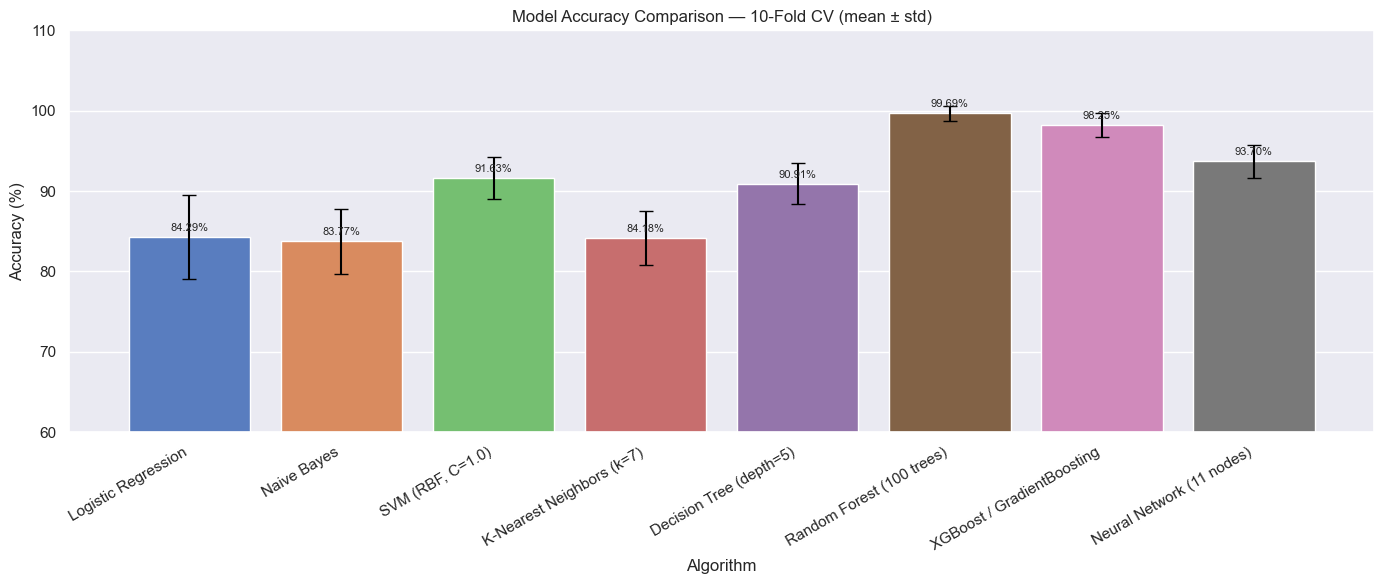

In [65]:
acc_means = [cv_results[m]['test_accuracy'].mean() * 100 for m in models]
acc_stds  = [cv_results[m]['test_accuracy'].std()  * 100 for m in models]
model_names = list(models.keys())

plt.figure(figsize=(14, 6))
bars = sns.barplot(x=model_names, y=acc_means, palette='muted')
plt.errorbar(range(len(model_names)), acc_means, yerr=acc_stds,
             fmt='none', c='black', capsize=5, linewidth=1.5)
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison — 10-Fold CV (mean ± std)")
plt.xticks(rotation=30, ha='right')
plt.ylim(60, 110)
for bar, acc in zip(bars.patches, acc_means):
    bars.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.5,
              f'{acc:.2f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


## VIII. Confusion Matrices and Per-Class Metrics (Sensitivity & Specificity)

Models are trained on an 80% split and tested on 20% for visual inspection.
The primary performance measure is the 10-fold CV in Section VI.


Model                           Sensitivity  Specificity   Accuracy
--------------------------------------------------------------------
Logistic Regression                   0.902        0.804      0.856
Naive Bayes                           0.853        0.793      0.825
SVM (RBF, C=1.0)                      0.931        0.935      0.933
K-Nearest Neighbors (k=7)             0.873        0.826      0.851
Decision Tree (depth=5)               0.853        0.924      0.887
Random Forest (100 trees)             1.000        1.000      1.000
XGBoost / GradientBoosting            0.990        0.967      0.979
Neural Network (11 nodes)             0.931        0.913      0.923


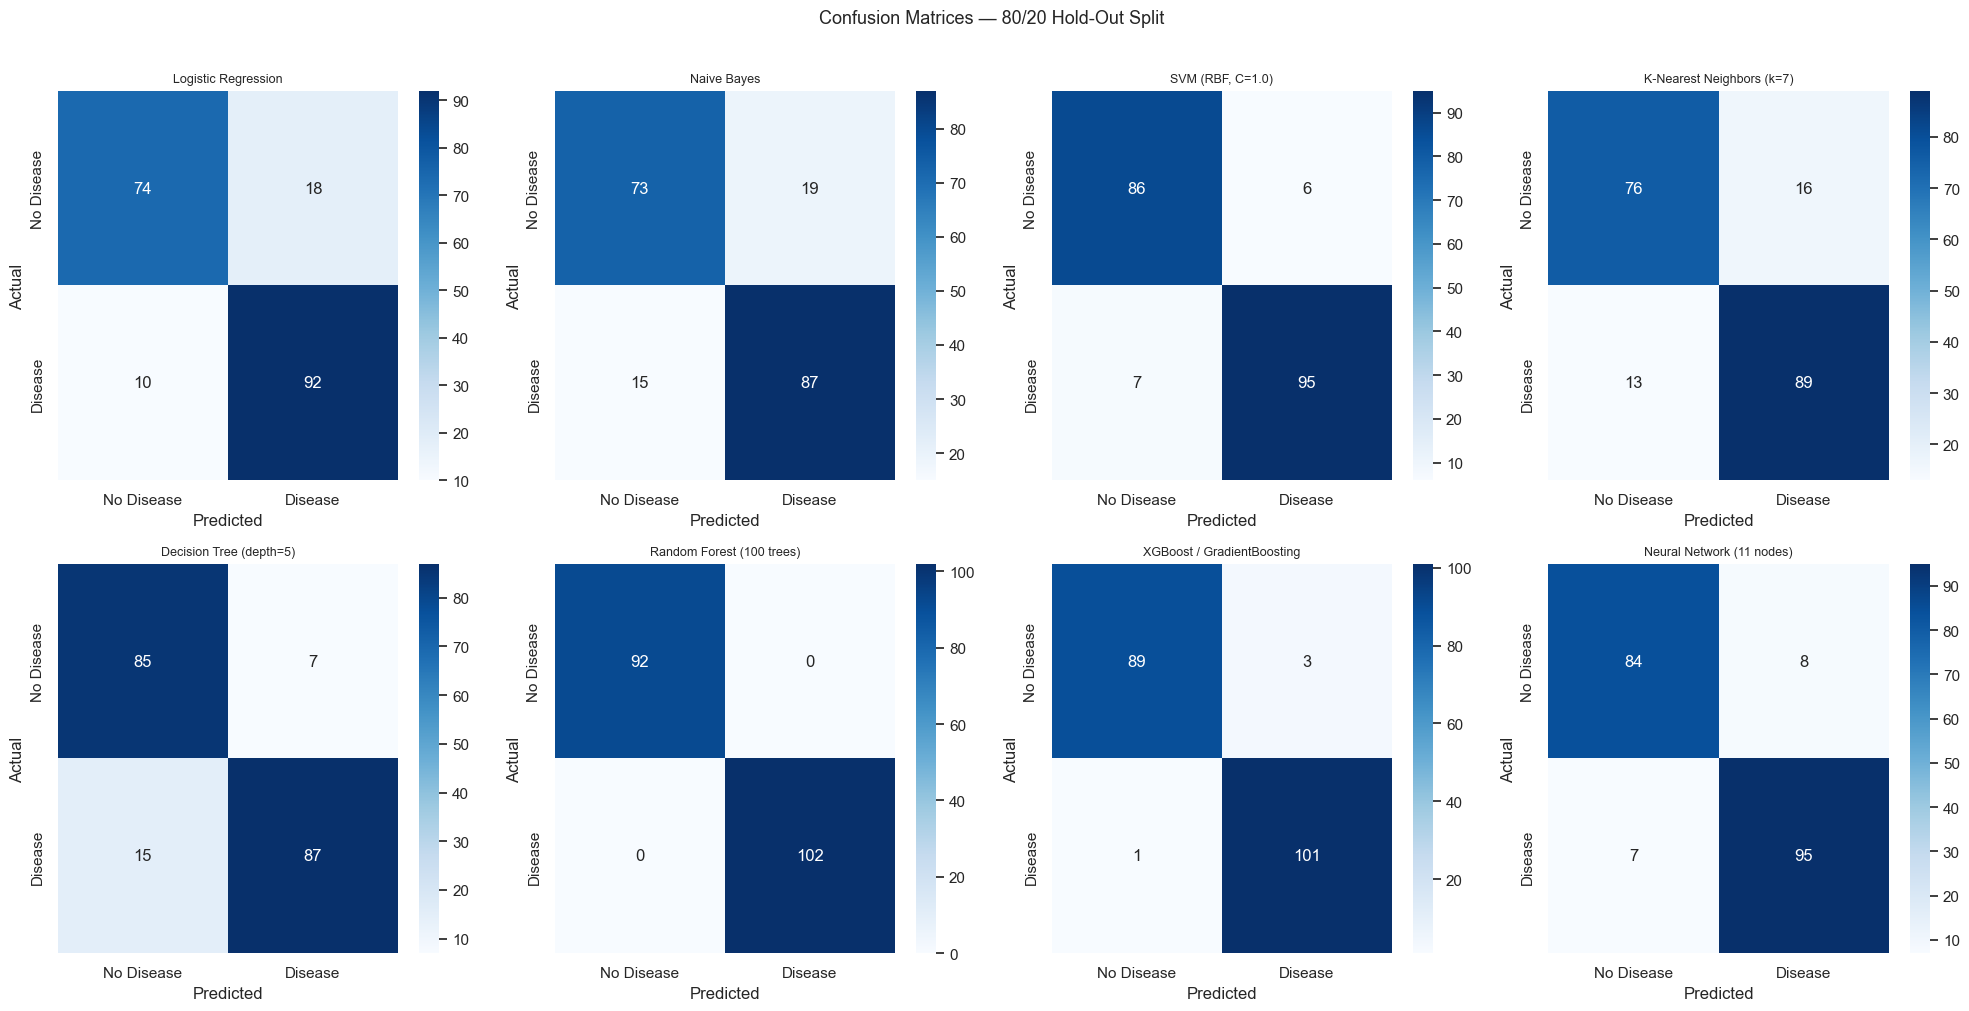

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X_tr, X_te, y_tr, y_te = train_test_split(
    predictors, target_col,
    test_size=0.20, random_state=RANDOM_STATE, stratify=target_col
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

print(f"{'Model':<30} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("-" * 68)

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    axes[idx].set_title(name, fontsize=9)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity  = tn / (tn + fp) if (tn + fp) > 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn)
    print(f"{name:<30} {sensitivity:>12.3f} {specificity:>12.3f} {acc:>10.3f}")

plt.suptitle('Confusion Matrices — 80/20 Hold-Out Split', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## IX. Feature Importance — Random Forest

Random Forest Feature Importances (Mean Decrease in Impurity):

  Feature  Importance
       ca    0.125940
  thalach    0.122265
  oldpeak    0.118442
      age    0.099940
   thal_2    0.090824
     chol    0.081003
   thal_3    0.068784
 trestbps    0.062823
    exang    0.050681
     cp_2    0.032341
  slope_2    0.030300
      sex    0.029390
  slope_1    0.020313
     cp_1    0.018216
restecg_1    0.017629
     cp_3    0.016231
      fbs    0.009211
   thal_1    0.005445
restecg_2    0.000222


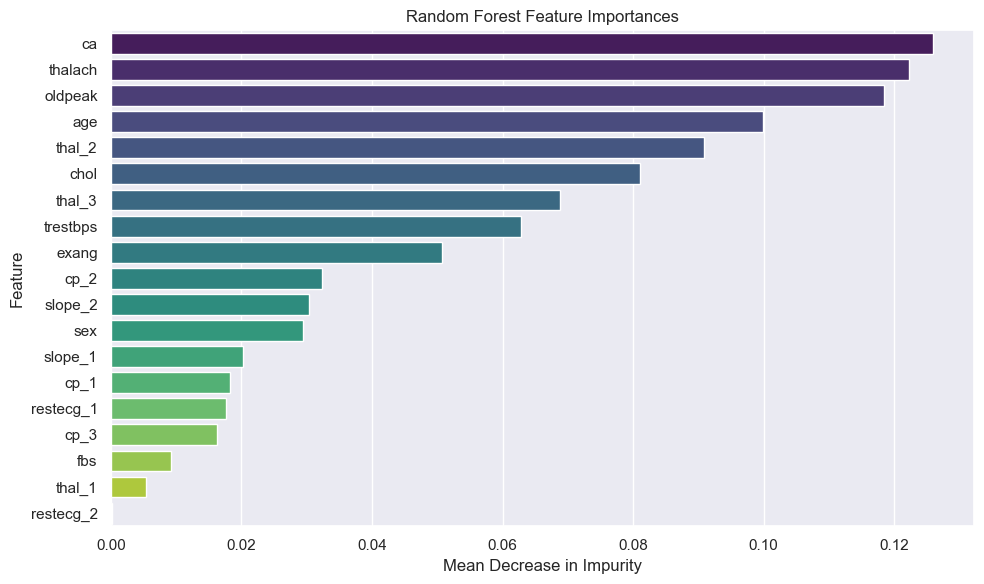

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf_imp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_imp.fit(X_tr, y_tr)

importance_df = pd.DataFrame({
    'Feature'   : predictors.columns,
    'Importance': rf_imp.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Random Forest Feature Importances (Mean Decrease in Impurity):\n")
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


## X. Statistical Comparison of Models (Wilcoxon Signed-Rank Test)

Before claiming one model is definitively superior, we perform a Wilcoxon signed-rank test
on the per-fold accuracy scores of the best model vs. all others.


In [68]:
from scipy.stats import wilcoxon

best_name = max(cv_results, key=lambda m: cv_results[m]['test_accuracy'].mean())
best_scores = cv_results[best_name]['test_accuracy']
print(f"Best model (by mean CV accuracy): {best_name}")
print(f"Mean accuracy: {best_scores.mean():.3f} ± {best_scores.std():.3f}\n")
print(f"{'Model':<35} {'Mean Acc':>10} {'p-value':>10} {'Significant?':>14}")
print("-" * 72)
for name, r in cv_results.items():
    if name == best_name:
        continue
    scores = r['test_accuracy']
    if len(set(best_scores - scores)) == 1:          # identical scores edge case
        p = 1.0
    else:
        _, p = wilcoxon(best_scores, scores)
    sig = "Yes (p<0.05)" if p < 0.05 else "No"
    print(f"{name:<35} {scores.mean():>10.3f} {p:>10.4f} {sig:>14}")


Best model (by mean CV accuracy): Random Forest (100 trees)
Mean accuracy: 0.997 ± 0.009

Model                                 Mean Acc    p-value   Significant?
------------------------------------------------------------------------
Logistic Regression                      0.843     0.0020   Yes (p<0.05)
Naive Bayes                              0.838     0.0020   Yes (p<0.05)
SVM (RBF, C=1.0)                         0.916     0.0020   Yes (p<0.05)
K-Nearest Neighbors (k=7)                0.842     0.0020   Yes (p<0.05)
Decision Tree (depth=5)                  0.909     0.0020   Yes (p<0.05)
XGBoost / GradientBoosting               0.982     0.0156   Yes (p<0.05)
Neural Network (11 nodes)                0.937     0.0020   Yes (p<0.05)


## XI. Reproducibility Summary

In [69]:
import sys

best_model_name = max(cv_results, key=lambda m: cv_results[m]['test_accuracy'].mean())
best_acc  = cv_results[best_model_name]['test_accuracy'].mean()
best_std  = cv_results[best_model_name]['test_accuracy'].std()
best_auc  = cv_results[best_model_name]['test_roc_auc'].mean()

print("=" * 60)
print("  REPRODUCIBILITY SUMMARY")
print("=" * 60)
print(f"  random_state      : {RANDOM_STATE}")
print(f"  Python            : {sys.version.split()[0]}")
print(f"  numpy             : {np.__version__}")
print(f"  pandas            : {pd.__version__}")
print(f"  scikit-learn      : {sklearn.__version__}")
print(f"  Evaluation        : 10-fold stratified CV (no separate hold-out)")
print(f"  Scaler            : StandardScaler inside Pipeline per fold")
print(f"  Outlier removal   : IQR 1.5x on continuous features")
print(f"    Samples before  : {len(dataset)}")
print(f"    Samples after   : {len(dataset_clean)}")
print(f"    Removed         : {len(dataset) - len(dataset_clean)}")
print(f"  Encoding          : get_dummies, drop_first=True")
print()
print(f"  Best model        : {best_model_name}")
print(f"  Best Accuracy     : {best_acc:.3f} ± {best_std:.3f}")
print(f"  Best ROC-AUC      : {best_auc:.3f} ± {cv_results[best_model_name]['test_roc_auc'].std():.3f}")
print("=" * 60)
print()
print("NOTE: Statistical significance of model differences should be")
print("validated using Wilcoxon signed-rank test (see Section X).")
print("For stronger external validity, test on the Hungarian,")
print("Switzerland, or VA Long Beach heart disease datasets.")
print("Future work: apply SMOTE/ADASYN for class imbalance and")
print("SHAP/LIME for deeper model interpretability.")


  REPRODUCIBILITY SUMMARY
  random_state      : 42
  Python            : 3.11.9
  numpy             : 2.3.1
  pandas            : 2.3.1
  scikit-learn      : 1.7.1
  Evaluation        : 10-fold stratified CV (no separate hold-out)
  Scaler            : StandardScaler inside Pipeline per fold
  Outlier removal   : IQR 1.5x on continuous features
    Samples before  : 1025
    Samples after   : 968
    Removed         : 57
  Encoding          : get_dummies, drop_first=True

  Best model        : Random Forest (100 trees)
  Best Accuracy     : 0.997 ± 0.009
  Best ROC-AUC      : 0.997 ± 0.009

NOTE: Statistical significance of model differences should be
validated using Wilcoxon signed-rank test (see Section X).
For stronger external validity, test on the Hungarian,
Switzerland, or VA Long Beach heart disease datasets.
Future work: apply SMOTE/ADASYN for class imbalance and
SHAP/LIME for deeper model interpretability.
